In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df1 = pd.read_csv("historical_data.csv")
df2 = pd.read_csv("fear_greed_index.csv")

In [3]:
df1["Timestamp IST"] = pd.to_datetime(
    df1["Timestamp IST"],
    dayfirst=True
)

df1["Date"] = df1["Timestamp IST"].dt.date

df2["date"] = pd.to_datetime(df2["date"]).dt.date

In [4]:
df = pd.merge(
    df1,
    df2,
    left_on="Date",
    right_on="date",
    how="left"
)

df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02


In [5]:
#Check missing values
df.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [6]:
#Average Profit/Loss by Market Sentiment
df.groupby("classification")["Closed PnL"].mean()

,Closed PnL
classification,
Extreme Fear,34.537862
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Neutral,34.307718


In [7]:
#Number of Trades
df["classification"].value_counts()

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


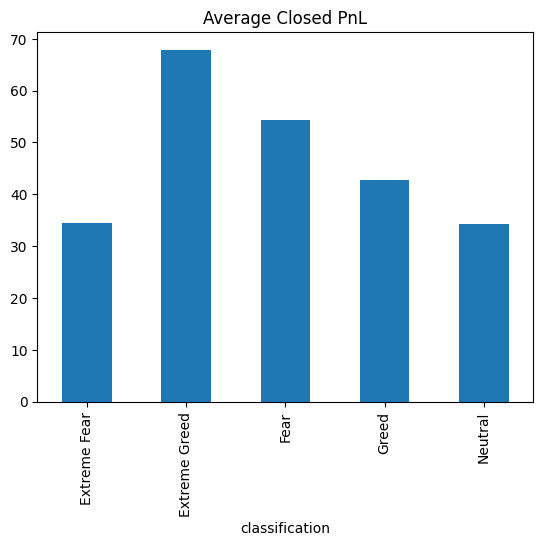

In [8]:
# Plot 1
df.groupby("classification")["Closed PnL"].mean().plot(kind="bar")
plt.title("Average Closed PnL")
plt.show()

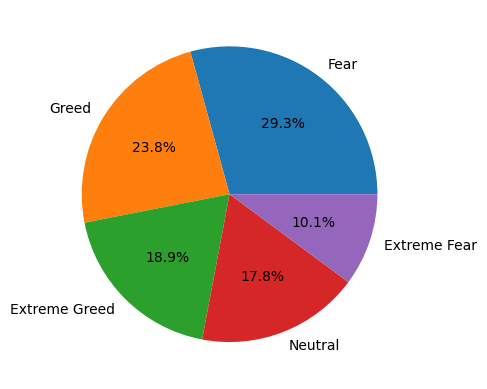

In [9]:
# Plot 2
df["classification"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.show()

In [10]:
df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date', 'timestamp', 'value', 'classification', 'date'],
      dtype='object')

## Observations

1. Trader profit changes with different market sentiments.
2. The number of trades varies during Fear, Greed, and Neutral market conditions.
3. The analysis shows that market sentiment influences trading behaviour.
4. These insights can help understand trader performance under different market conditions.

## Conclusion

By combining trading data with the Fear & Greed Index, we can observe how market sentiment affects trader behaviour and profitability. Such analysis can support better trading decisions.